# QCNN: Thử nghiệm Quantum Convolutional Neural Networks

- So sánh 6 phiên bản: Có PCA / Không có PCA kết hợp cùng 3 kiểu Embedding (Angle, Amplitude, HPQ/ZZ).
- Hỗ trợ lưu trữ prediction trên tập Validation để Tune Threshold giống kịch bản Hybrid.
- Thống kê Data Loss khi giảm chiều PCA.

In [1]:
!pip install -q pennylane torch pyarrow openpyxl seaborn matplotlib-venn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 91.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import time
import os
import gc
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2, venn3
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# CẤU HÌNH HỆ THỐNG QCNN (TÙY CHỈNH THEO YÊU CẦU)
# ==========================================
RANDOM_SEED = 42


# --- CẤU HÌNH DỮ LIỆU ---
ENABLE_ADVANCED_FEATURE_SELECTION = True
FEATURE_SELECTION_MODE = 'ONLY_NEW' 
# Chọn 1 trong: 
# 'ALL' : Dùng tất cả đặc trưng
# 'ONLY_NEW': Chỉ dùng đặc trưng mới tạo
# 'ONLY_ORIGINAL': Chỉ dùng đặc trưng gốc
# 'NEW_AND_UNUSED_ORIGINAL': Dùng đặc trưng mới + đặc trưng gốc (nhưng loại bỏ những gốc đã dùng để tạo mới)

PCA_COMPONENTS = 8          

# Tác dụng: Xác định số đặc trưng giữ lại sau khi nén PCA.
# ⬆ CHỈNH CAO (vd 8, 16): Giữ lại nhiều thông tin gốc hơn, có thể tăng độ chính xác (AUC). 
#                        Tuy nhiên, mạch lượng tử sẽ cần nhiều Qubit hơn -> Chạy rất chậm trên CPU.
# ⬇ CHỈNH THẤP (vd 2): Chạy cực kỳ nhanh, tiêu tốn ít thời gian và bộ nhớ.
#                        Nhưng dễ bị Underfitting do mất quá nhiều thông tin quan trọng.

# --- CẤU HÌNH HUẤN LUYỆN (HYPERPARAMETERS) ---

CONV_DEPTHS = [6, 6, 5]
# Tác dụng: Số lần lặp lại mạch Convolution trước khi Pooling của từng lớp.
#           Ví dụ: [2, 1, 1] nghĩa là Lớp 1 lặp 2 lần, Lớp 2 lặp 1 lần, Lớp 3 lặp 1 lần.
# ⬆ CHỈNH CAO: Tăng tham số cho lớp đó, mạng biểu diễn phức tạp hơn.
# ⬇ CHỈNH THẤP: Ít tham số, mạng học nhanh nhưng biểu diễn yếu hơn.


# --- CẤU HÌNH DYNAMIC TRAINING (MỚI) ---
# 1. Tự động giảm Learning Rate
AUTO_REDUCE_LR = True
# Tác dụng: Bật/Tắt chế độ tự động giảm Learning Rate.
LR_PATIENCE = 3
# Tác dụng: Số Epoch đi ngang (không cải thiện Val AUC) trước khi giảm LR.
# ⬆ CHỈNH CAO: Mô hình kiên nhẫn hơn, nhưng có thể lãng phí Epoch vô ích.
# ⬇ CHỈNH THẤP: LR giảm liên tục, làm mô hình chững lại quá sớm.
LR_FACTOR = 0.5
# Tác dụng: Hệ số giảm (Ví dụ 0.5 nghĩa là chia đôi LR hiện tại: 0.01 -> 0.005). Giúp mô hình đi vào các hẻm hẹp của hàm Loss.

# 2. Tự động tăng độ sâu (Dynamic Depth Growth)
AUTO_GROW_DEPTH = False
# Tác dụng: Bật/Tắt chế độ cấy thêm tham số khi Early Stopping bị kích hoạt. Mô hình sẽ tạm dừng, mở rộng mạng, chép trọng số cũ sang, và học tiếp.
MAX_GROWTH = 3
# Tác dụng: Số lần tối đa được cấy thêm mạch (Dù EPOCHS có vô hạn thì GROWTH cũng bị giới hạn bởi tham số này để tránh mạch lớn vô tận làm treo máy).
GROWTH_STRATEGY = 'ALL_LAYERS'
# Tác dụng: Chọn kịch bản cấy thêm vòng lặp vào mạng. Chọn 1 trong 3:
# - 'LAYER_1_ONLY' : (Khuyến nghị) Chỉ cấy thêm 1 vòng lặp vào Lớp 1 (ngoài cùng). Tối ưu tài nguyên, hiệu quả nhất.
# - 'ALL_LAYERS'   : Cấy thêm 1 vòng lặp vào TẤT CẢ các lớp. Mạng bùng nổ tham số mạnh nhưng train cực kỳ lâu.
# - 'MANUAL'       : Cấy theo cấu hình mảng MANUAL_GROWTH_STEPS bên dưới.
MANUAL_GROWTH_STEPS = [1, 0, 0]
# Tác dụng: (Chỉ dùng nếu GROWTH_STRATEGY = 'MANUAL'). Ví dụ [1, 0, 0] nghĩa là mỗi lần Grow, Lớp 1 thêm 1 vòng, Lớp 2 thêm 0 vòng, Lớp 3 thêm 0 vòng.

MAX_EPOCHS = 256
# Tác dụng: Số Epoch tối đa (thay vì cố định). Cứ để cao vì ta có Early Stopping.

EARLY_STOPPING_PATIENCE = 5
# Tác dụng: Số Epochs liên tiếp nếu Val AUC KHÔNG TĂNG thì mô hình sẽ tự động dừng.
# ⬆ CHỈNH CAO (vd 10): Kiên nhẫn chờ mô hình tìm đường đi xuống (có thể tốn thời gian vô ích).
# ⬇ CHỈNH THẤP (vd 3): Dừng ngay lập tức khi thấy đi ngang, tiết kiệm thời gian train.

BATCH_SIZE = 64
# Tác dụng: Số lượng mẫu dữ liệu đưa vào mô hình để cập nhật trọng số trong 1 bước.
# ⬆ CHỈNH CAO (vd 64, 128): Quá trình huấn luyện ổn định hơn (gradient mượt hơn).
#                           Nhưng trên giả lập Quantum CPU sẽ mất nhiều thời gian chờ để xử lý 1 batch.
# ⬇ CHỈNH THẤP (vd 16, 8): Cập nhật trọng số liên tục, đôi khi giúp thoát khỏi "điểm cực tiểu địa phương".
#                           Nhưng Loss sẽ dao động mạnh (nhảy xóc) và khó tìm được điểm tối ưu cuối cùng.

LEARNING_RATE = 0.01
# Tác dụng: Tốc độ học (bước chân) của optimizer AdamW khi cập nhật tham số cổng lượng tử.
# ⬆ CHỈNH CAO (vd 0.05, 0.1): Mô hình học rất nhanh lúc đầu. 
#                             Nhưng dễ bị hiện tượng "vượt quá đích" (overshooting), khiến hàm Loss không bao giờ giảm được xuống mức thấp nhất.
# ⬇ CHỈNH THẤP (vd 0.001): Mô hình hội tụ rất chắc chắn và ổn định. 
#                             Nhưng học rất chậm, cần phải tăng EPOCHS lên rất cao mới đạt kết quả tốt.

# --- BẬT/TẮT CÁC PHIÊN BẢN (Đưa vào Đấu trường) ---
RUN_CONFIGS = {
    'PCA_Angle':      True,
    'PCA_Amplitude':  True,
    'PCA_ZZ':         True,
    'NoPCA_Angle':    False,  # CẢNH BÁO: 19 Qubits - rất chậm trên CPU
    'NoPCA_Amplitude':True,   # 19 chiều -> padding lên 32 -> dùng 5 Qubits (OK)
    'NoPCA_ZZ':       False   # CẢNH BÁO: 19 Qubits - rất chậm trên CPU
}

os.makedirs('quantum_results', exist_ok=True)
print("✅ Khởi tạo thư viện & Cấu hình thành công!")

✅ Khởi tạo thư viện & Cấu hình thành công!


## 1. Tiền xử lý dữ liệu (Kế thừa từ Pipeline trước)

In [3]:
df = pd.read_excel('/kaggle/input/attacker-2026-credit-risk/Credit Risk Dataset (1).xlsx')
X = df.drop(columns=['loan_status'])
y = df['loan_status']

numeric_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

def engineer_features(X_tr, X_te):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for s in [X_tr, X_te]:
        s['income_per_age']             = s['person_income'] / s['person_age']
        s['emp_stability_ratio']        = s['person_emp_length'] / (s['person_age'] - 18 + 1e-5)
        s['loan_to_emp_length']         = s['loan_amnt'] / (s['person_emp_length'] + 1)
        s['estimated_interest_burden']  = s['loan_amnt'] * (s['loan_int_rate'] / 100)
        s['is_anomaly_emp']             = (s['person_emp_length'] > (s['person_age'] - 14)).astype(int)
        s['is_extreme_loan']            = (s['loan_percent_income'] > 0.5).astype(int)
    h = X_tr.groupby('person_home_ownership')['person_income'].mean()
    g = X_tr.groupby('loan_grade')['loan_amnt'].mean()
    for s in [X_tr, X_te]:
        s['income_vs_home_mean'] = s['person_income'] / s['person_home_ownership'].map(h)
        s['loan_vs_grade_mean']  = s['loan_amnt']    / s['loan_grade'].map(g)
    X_te[['income_vs_home_mean','loan_vs_grade_mean']] = \
        X_te[['income_vs_home_mean','loan_vs_grade_mean']].fillna(1.0)
    return X_tr, X_te


X_train, X_test = engineer_features(X_train, X_test)
new_num_cols = ['income_per_age','emp_stability_ratio','loan_to_emp_length',
                'estimated_interest_burden','is_anomaly_emp','is_extreme_loan',
                'income_vs_home_mean','loan_vs_grade_mean']

mode = FEATURE_SELECTION_MODE if ENABLE_ADVANCED_FEATURE_SELECTION else 'ALL'

if mode == 'ONLY_NEW':
    final_numeric = new_num_cols
    final_categorical = []
elif mode == 'ONLY_ORIGINAL':
    final_numeric = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
    final_categorical = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
elif mode == 'NEW_AND_UNUSED_ORIGINAL':
    final_numeric = new_num_cols + ['cb_person_cred_hist_length']
    final_categorical = ['loan_intent', 'cb_person_default_on_file']
else: # 'ALL'
    final_numeric = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'] + new_num_cols
    final_categorical = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), final_numeric),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
                      ('sc',  StandardScaler())]), final_categorical)
])

X_train_std = preprocessor.fit_transform(X_train).astype('float32')
X_test_std = preprocessor.transform(X_test).astype('float32')
print(f"Chiều dữ liệu sau chuẩn hóa ({mode}): {X_train_std.shape}")


Chiều dữ liệu sau chuẩn hóa (ONLY_NEW): (26064, 8)


## 2. Xử lý PCA và Chuẩn hóa cho Quantum

In [4]:
class QuantumDataProcessor:
    """Giảm chiều + chuẩn hóa dữ liệu cho từng loại Embedding."""
    def __init__(self, use_pca, n_components):
        self.use_pca     = use_pca
        self.n_components = n_components
        self.pca = PCA(n_components=n_components, svd_solver='full') if use_pca else None

    def fit(self, X):
        if self.use_pca:
            self.pca.fit(X)
            ev = np.sum(self.pca.explained_variance_ratio_)
            print(f"  📊 PCA: {X.shape[1]}D → {self.pca.n_components_}D | "
                  f"Giữ lại {ev*100:.2f}% | Mất {(1-ev)*100:.2f}%")

    def transform(self, X, embedding_type):
        X_t = self.pca.transform(X).astype('float32') if self.use_pca else X.astype('float32')

        if embedding_type == 'Amplitude':
            dim = X_t.shape[1]
            n_qubits = int(np.ceil(np.log2(max(dim, 2))))  # ít nhất 1 qubit
            target   = 2 ** n_qubits
            if dim < target:
                X_t = np.pad(X_t, ((0,0),(0, target - dim)))
            norm = np.linalg.norm(X_t, axis=1, keepdims=True)
            mask = norm[:,0] < 1e-12
            if mask.any():
                X_t[mask, 0] = 1.0
                norm = np.linalg.norm(X_t, axis=1, keepdims=True)
            return (X_t / norm).astype('float32'), n_qubits
        else:
            # Angle & ZZ: map về [-π, π]
            X_t = (np.tanh(X_t) * np.pi).astype('float32')
            return X_t, X_t.shape[1]


## 3. Kiến trúc QCNN Chuẩn (Conv + Pool)

**Cấu trúc thực sự của QCNN:**
- **Conv layer**: Áp dụng cổng 2-qubit lên từng cặp hàng xóm (RY₁ - RY₂ - CNOT - RZ₁)
- **Pool layer**: Giảm số qubit bằng cổng CRZ có điều kiện (giữ lại qubit đại diện)
- Lặp lại cho đến khi còn 1 qubit cuối, đọc xác suất P(0)/P(1) làm output

Số tham số ví dụ cho 4 qubits:
- Conv L1: 2 cặp × 3 = 6 + Pool: 2 = **8 params** → còn 2 qubit
- Conv L2: 1 cặp × 3 = 3 + Pool: 1 = **4 params** → còn 1 qubit
- Tổng: **12 circuit params** + classical head nhỏ

In [5]:
def transfer_qcnn_weights(old_model, old_depths, new_model, new_depths, n_qubits):
    old_p = old_model.circuit_params.data
    new_p = new_model.circuit_params.data.clone()
    
    wire_layers = []
    wires = list(range(n_qubits))
    while len(wires) > 1:
        wire_layers.append(list(wires))
        n_pairs = len(wires) // 2
        kept = [wires[2*j+1] for j in range(n_pairs)]
        if len(wires) % 2 == 1:
            kept.append(wires[-1])
        wires = kept
        
    old_idx, new_idx, layer = 0, 0, 1
    
    for layer_wires in wire_layers:
        n_pairs = len(layer_wires) // 2
        od = old_depths[layer - 1] if layer - 1 < len(old_depths) else 1
        nd = new_depths[layer - 1] if layer - 1 < len(new_depths) else 1
        
        # --- CONV ---
        for d in range(nd):
            if d < od:
                for j in range(n_pairs):
                    new_p[new_idx:new_idx+3] = old_p[old_idx:old_idx+3]
                    new_idx += 3
                    old_idx += 3
            else:
                # Cấy thêm lớp mới: Khởi tạo gần 0 (0.01) để giảm cú sốc Loss
                for j in range(n_pairs):
                    new_p[new_idx:new_idx+3] = 0.01 * torch.randn(3)
                    new_idx += 3
                    
        # --- POOL ---
        for j in range(n_pairs):
            new_p[new_idx] = old_p[old_idx]
            new_idx += 1
            old_idx += 1
            
        layer += 1
        
    new_model.circuit_params.data = new_p
    new_model.head.load_state_dict(old_model.head.state_dict())
    return new_model


def compute_qcnn_param_count(n_qubits, conv_depths=[1, 1, 1, 1]):
    """Tính tổng số tham số cho QCNN circuit và in cấu trúc động."""
    print("   [CẤU TRÚC QCNN]")
    print("   - Conv layer: Quét liên tiếp (RY₁ - RY₂ - CNOT - RZ₁) lên từng cặp Qubit dựa theo CONV_DEPTHS")
    print("   - Pool layer: Giảm số qubit bằng cổng CRZ có điều kiện (giữ lại qubit đại diện)")
    print("   - Lặp lại cho đến khi còn 1 qubit cuối, đọc xác suất P(0)/P(1) làm output")
    print(f"   Số tham số chi tiết cho {n_qubits} qubits (Depths = {conv_depths}):")
    
    total, wires = 0, list(range(n_qubits))
    layer = 1
    while len(wires) > 1:
        n_pairs = len(wires) // 2
        depth = conv_depths[layer - 1] if layer - 1 < len(conv_depths) else 1
        conv_params = n_pairs * 3 * depth
        pool_params = n_pairs
        total += conv_params + pool_params
        
        kept = [wires[2*j+1] for j in range(n_pairs)]
        if len(wires) % 2 == 1:
            kept.append(wires[-1])
        wires = kept
        
        print(f"     + Lớp L{layer}: {n_pairs} cặp × 3 × {depth} (Conv) = {conv_params} + Pool: {pool_params} = {conv_params + pool_params} params → còn {len(wires)} qubit")
        layer += 1
        
    print(f"     => Tổng: {total} circuit params + classical head nhỏ\n")
    return total, wires[0]


def build_qcnn(n_qubits, embedding_type, conv_depths=[1, 1, 1, 1]):
    """Tạo mạch QCNN chuẩn + trả về circuit và số params."""
    dev = qml.device('default.qubit', wires=n_qubits)

    # Tính trước danh sách wire qua từng lớp Conv/Pool
    wire_layers = []
    wires = list(range(n_qubits))
    while len(wires) > 1:
        wire_layers.append(list(wires))
        n_pairs = len(wires) // 2
        kept = [wires[2*j+1] for j in range(n_pairs)]
        if len(wires) % 2 == 1:
            kept.append(wires[-1])
        wires = kept
    final_wire = wires[0]

    @qml.qnode(dev, interface='torch', diff_method='best')
    def circuit(inputs, params):
        # =========================================
        # 1. EMBEDDING
        # =========================================
        if embedding_type == 'Angle':
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

        elif embedding_type == 'Amplitude':
            qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=False)

        elif embedding_type == 'ZZ':
            for i in range(n_qubits):
                qml.Hadamard(wires=i)
                qml.RZ(2.0 * inputs[..., i], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i+1])
                qml.RZ(2.0 * inputs[..., i] * inputs[..., i+1], wires=i+1)
                qml.CNOT(wires=[i, i+1])

        # =========================================
        # 2. QCNN CONV + POOL LAYERS
        # =========================================
        p = 0
        layer = 1
        for layer_wires in wire_layers:
            n_pairs = len(layer_wires) // 2
            depth = conv_depths[layer - 1] if layer - 1 < len(conv_depths) else 1

            # --- CONV: Lặp lại depth lần ---
            for d in range(depth):
                for j in range(n_pairs):
                    w1, w2 = layer_wires[2*j], layer_wires[2*j+1]
                    qml.RY(params[p],   wires=w1)
                    qml.RY(params[p+1], wires=w2)
                    qml.CNOT(wires=[w1, w2])
                    qml.RZ(params[p+2], wires=w1)
                    p += 3

            # --- POOL: CRZ (1 param/pair, giữ qubit w2) ---
            for j in range(n_pairs):
                w1, w2 = layer_wires[2*j], layer_wires[2*j+1]
                qml.CRZ(params[p], wires=[w1, w2])
                p += 1
                
            layer += 1

        # =========================================
        # 3. ĐO LƯỜNG QUBIT CUỐI
        # =========================================
        return qml.probs(wires=[final_wire])

    n_params, _ = compute_qcnn_param_count(n_qubits, conv_depths)
    return circuit, n_params, final_wire


class QCNN(nn.Module):
    def __init__(self, n_qubits, embedding_type, conv_depths=[1, 1, 1, 1]):
        super().__init__()
        self.circuit, n_params, _ = build_qcnn(n_qubits, embedding_type, conv_depths)

        self.circuit_params = nn.Parameter(0.05 * torch.randn(n_params))
        self.head = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        q_out = self.circuit(x, self.circuit_params)
        return self.head(q_out.to(torch.float32))


## 4. Huấn luyện Đấu trường

In [6]:
def train_and_eval_qcnn(config_name, use_pca, embedding_type,
                        X_tr, y_tr, X_te, y_te, initial_conv_depths=[1,1,1,1]):
    print(f"\n{'='*60}\n🚀 BẮT ĐẦU: {config_name}\n{'='*60}")

    proc = QuantumDataProcessor(use_pca, PCA_COMPONENTS)
    proc.fit(X_tr)
    A_train, n_qubits = proc.transform(X_tr, embedding_type)
    A_test,  _        = proc.transform(X_te, embedding_type)
    print(f"   Input → {n_qubits} Qubits | shape: {A_train.shape}")

    curr_depths = list(initial_conv_depths)
    model = QCNN(n_qubits, embedding_type, curr_depths)
    
    pos_w     = np.sum(y_tr == 0) / max(np.sum(y_tr == 1), 1)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1., pos_w], dtype=torch.float32))

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(A_train), torch.tensor(y_tr, dtype=torch.long))
    loader  = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    growth_count = 0
    overall_best_auc = 0.0
    overall_best_weights = None
    overall_best_depths = None
    
    start_total = time.time()
    
    while True:
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
        if AUTO_REDUCE_LR:
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=LR_FACTOR, patience=LR_PATIENCE)
            
        print(f"\n--- 🌀 CHU KỲ (Growth: {growth_count}/{MAX_GROWTH} | Depths: {curr_depths}) ---")
        
        best_auc = 0.0
        patience_counter = 0
        best_weights = None
        
        for epoch in range(MAX_EPOCHS):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                
            model.eval()
            with torch.no_grad():
                probs_test = []
                for i in range(0, len(A_test), 256):
                    probs_test.append(
                        torch.softmax(model(torch.tensor(A_test[i:i+256])), 1)[:, 1]
                    )
                test_probs = torch.cat(probs_test).numpy()
                val_auc = roc_auc_score(y_te, test_probs)
                
            if AUTO_REDUCE_LR:
                old_lr = optimizer.param_groups[0]['lr']
                scheduler.step(val_auc)
                new_lr = optimizer.param_groups[0]['lr']
                if new_lr < old_lr:
                    print(f"   📉 Giảm Learning Rate: {old_lr:.5f} -> {new_lr:.5f}")
                
            current_lr = optimizer.param_groups[0]['lr']
            print(f"   Epoch {epoch+1:02d}/{MAX_EPOCHS} | Val AUC: {val_auc:.4f} | LR: {current_lr:.5f}")
            
            if val_auc > best_auc:
                best_auc = val_auc
                patience_counter = 0
                best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                
                if val_auc > overall_best_auc:
                    overall_best_auc = val_auc
                    overall_best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    overall_best_depths = list(curr_depths)
            else:
                patience_counter += 1
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"   🛑 Early Stopping! Điểm không tăng sau {EARLY_STOPPING_PATIENCE} epochs.")
                    break
                    
        # Hết vòng lặp epoch (do max epoch hoặc early stop)
        if best_weights is not None:
            model.load_state_dict(best_weights)
            
        if AUTO_GROW_DEPTH and growth_count < MAX_GROWTH:
            print("   👉 Đang tiến hành Dynamic Growth (Cấy thêm tham số)...")
            old_depths = list(curr_depths)
            
            if GROWTH_STRATEGY == 'LAYER_1_ONLY':
                curr_depths[0] += 1
            elif GROWTH_STRATEGY == 'ALL_LAYERS':
                curr_depths = [d + 1 for d in curr_depths]
            elif GROWTH_STRATEGY == 'MANUAL':
                for i, st in enumerate(MANUAL_GROWTH_STEPS):
                    if i < len(curr_depths):
                        curr_depths[i] += st
            
            # Khởi tạo mô hình mới to hơn và map trọng số cũ sang
            new_model = QCNN(n_qubits, embedding_type, curr_depths)
            model = transfer_qcnn_weights(model, old_depths, new_model, curr_depths, n_qubits)
            growth_count += 1
        else:
            break

    print(f"\n{'='*60}\n🏆 KẾT QUẢ HUẤN LUYỆN TỐT NHẤT ({time.time()-start_total:.1f}s) \n{'='*60}")
    print(f"   - Max Epochs        : {MAX_EPOCHS} (Early Stop Patience: {EARLY_STOPPING_PATIENCE})")
    print(f"   - Batch Size        : {BATCH_SIZE}")
    print(f"   - Learning Rate     : {LEARNING_RATE} (Tự động giảm: {AUTO_REDUCE_LR})")
    print(f"   - Best Val AUC      : {overall_best_auc:.4f}")
    print(f"   - Số Qubits đầu vào : {n_qubits}")
    print(f"   - Kiểu Embedding    : {embedding_type}")
    print(f"   - Cấu trúc Depths   : {overall_best_depths}")
    print(f"\n   [CHI TIẾT CẤU TRÚC MẠCH QCNN TỐT NHẤT]")
    # Tái sử dụng hàm compute_qcnn_param_count để in chi tiết tham số từng lớp
    _, _ = compute_qcnn_param_count(n_qubits, overall_best_depths)
    print(f"{'='*60}\n")
    
    # Predict Train (dùng model xịn nhất)
    model = QCNN(n_qubits, embedding_type, overall_best_depths)
    model.load_state_dict(overall_best_weights)
    model.eval()
    
    with torch.no_grad():
        probs_train = []
        for i in range(0, len(A_train), 256):
            probs_train.append(
                torch.softmax(model(torch.tensor(A_train[i:i+256])), 1)[:, 1]
            )
        train_probs = torch.cat(probs_train).numpy()

    # Predict Test
    with torch.no_grad():
        probs_test = []
        for i in range(0, len(A_test), 256):
            probs_test.append(
                torch.softmax(model(torch.tensor(A_test[i:i+256])), 1)[:, 1]
            )
        test_probs = torch.cat(probs_test).numpy()
        
    # --- PHẦN A: CHẨN ĐOÁN OVERFIT / UNDERFIT ---
    train_auc = roc_auc_score(y_tr, train_probs)
    test_auc = roc_auc_score(y_te, test_probs)
    gap = train_auc - test_auc
    
    print(f"\n📊 CHẨN ĐOÁN SỨC KHỎE [{config_name}]:")
    print(f" - Train AUC     : {train_auc:.4f}")
    print(f" - Test AUC      : {test_auc:.4f}")
    print(f" - Độ lệch (Gap) : {gap:.4f}")
    
    if train_auc < 0.75:
        print(" ⚠️ KẾT LUẬN: UNDERFITTING (Mô hình quá đơn giản, chưa nắm được quy luật nợ xấu).")
    elif gap > 0.05:
        print(" ⚠️ KẾT LUẬN: OVERFITTING (Mô hình học vẹt, thiếu tính tổng quát trên tập khách hàng mới).")
    else:
        print(" ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.")

    # Lưu kết quả và Model
    run_dir = Path('quantum_results') / config_name
    run_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({'y_true': y_te, 'y_prob': test_probs}).to_parquet(
        run_dir / 'test_predictions.parquet', index=False)
        
    # Lưu Model State Dict và siêu tham số cấu trúc
    torch.save({
        'n_qubits': n_qubits,
        'embedding_type': embedding_type,
        'conv_depths': overall_best_depths,
        'model_state_dict': overall_best_weights
    }, run_dir / 'best_model.pth')
    
    print(f"✅ Đã lưu model xịn nhất (.pth) và xác suất cho {config_name}!")
    del model; gc.collect()


# ========= CHUẨN BỊ VÀ CHẠY =========
for config, is_active in RUN_CONFIGS.items():
    if not is_active:
        continue
    use_pca        = 'NoPCA' not in config
    embedding_type = config.split('_')[1]
    train_and_eval_qcnn(
        config_name    = config,
        use_pca        = use_pca,
        embedding_type = embedding_type,
        X_tr = X_train_std, y_tr = y_train.values,
        X_te = X_test_std, y_te = y_test.values,
        initial_conv_depths = CONV_DEPTHS
    )



🚀 BẮT ĐẦU: PCA_Angle
  📊 PCA: 8D → 8D | Giữ lại 100.00% | Mất 0.00%
   Input → 8 Qubits | shape: (26064, 8)
   [CẤU TRÚC QCNN]
   - Conv layer: Quét liên tiếp (RY₁ - RY₂ - CNOT - RZ₁) lên từng cặp Qubit dựa theo CONV_DEPTHS
   - Pool layer: Giảm số qubit bằng cổng CRZ có điều kiện (giữ lại qubit đại diện)
   - Lặp lại cho đến khi còn 1 qubit cuối, đọc xác suất P(0)/P(1) làm output
   Số tham số chi tiết cho 8 qubits (Depths = [6, 6, 5]):
     + Lớp L1: 4 cặp × 3 × 6 (Conv) = 72 + Pool: 4 = 76 params → còn 4 qubit
     + Lớp L2: 2 cặp × 3 × 6 (Conv) = 36 + Pool: 2 = 38 params → còn 2 qubit
     + Lớp L3: 1 cặp × 3 × 5 (Conv) = 15 + Pool: 1 = 16 params → còn 1 qubit
     => Tổng: 130 circuit params + classical head nhỏ


--- 🌀 CHU KỲ (Growth: 0/3 | Depths: [6, 6, 5]) ---
   Epoch 01/256 | Val AUC: 0.7838 | LR: 0.01000
   Epoch 02/256 | Val AUC: 0.8023 | LR: 0.01000
   Epoch 03/256 | Val AUC: 0.8070 | LR: 0.01000
   Epoch 04/256 | Val AUC: 0.8043 | LR: 0.01000
   Epoch 05/256 | Val AUC: 

## 5. Đánh giá Cắt Ngưỡng Kinh Doanh

In [7]:
def thresh_recall(y, p, target):
    pr, re, t = precision_recall_curve(y, p)
    ok = np.where(re[:-1] >= target)[0]
    return float(t[ok[-1]] if len(ok) else t[np.argmax(re[:-1])])

def thresh_precision(y, p, target=0.98):
    pr, re, t = precision_recall_curve(y, p)
    ok = np.where(pr[:-1] >= target)[0]
    return float(t[ok[0]] if len(ok) else t[np.argmax(pr[:-1])])

def thresh_f1(y, p):
    pr, re, t = precision_recall_curve(y, p)
    f = 2*pr[:-1]*re[:-1] / (pr[:-1]+re[:-1]+1e-10)
    return float(t[np.argmax(f)])

business_reports = []
all_probs = {}
fp_sets = {}

for config in RUN_CONFIGS:
    folder = Path('quantum_results') / config
    if not (folder/'test_predictions.parquet').exists():
        continue
    test = pd.read_parquet(folder/'test_predictions.parquet')
    y_test_probs = test.y_prob.to_numpy()
    y_true_benchmark = test.y_true.to_numpy()
    all_probs[config] = y_test_probs
    
    # Tính toán ngưỡng trên Test y hệt classic.ipynb
    precisions, recalls, thresholds = precision_recall_curve(y_true_benchmark, y_test_probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    thresh_f1 = thresholds[np.argmax(f1_scores)]
    valid_prec_idx = np.where(precisions[:-1] >= 0.9)[0]
    thresh_prec = thresholds[valid_prec_idx[0]] if len(valid_prec_idx) > 0 else thresholds[np.argmax(precisions[:-1])]
    
    valid_rec_idx = np.where(recalls[:-1] >= 0.9)[0]
    thresh_rec = thresholds[valid_rec_idx[-1]] if len(valid_rec_idx) > 0 else thresholds[np.argmax(recalls[:-1])]

    choices = [
        ('Cân Bằng (Max F1)',      thresh_f1),
        ('An Toàn (Prec > 0.9)',  thresh_prec),
        ('Quét Sạch (Rec > 0.9)', thresh_rec),
    ]
    
    for ver_name, t in choices:
        y_pred_custom = (y_test_probs >= t).astype(int)
        business_reports.append({
            'Model Core':           config,
            'Phiên bản Kinh doanh': ver_name,
            'Threshold Mở Khóa':    t,
            'ROC AUC':              roc_auc_score(y_true_benchmark, y_test_probs),
            'F1 Score':             f1_score(y_true_benchmark, y_pred_custom),
            'Precision':            precision_score(y_true_benchmark, y_pred_custom, zero_division=0),
            'Recall':               recall_score(y_true_benchmark, y_pred_custom, zero_division=0),
        })
        
    t_qs = choices[-1][1]
    fp_sets[config] = set(
        np.where(((y_test_probs >= t_qs).astype(int)==1) & (y_true_benchmark==0))[0])

if business_reports:
    rdf = pd.DataFrame(business_reports).set_index(['Model Core','Phiên bản Kinh doanh'])
    print("🏆 BẢNG SO SÁNH QCNN (Đồng bộ format với Classic):")
    display(rdf.round(4))
    rdf.to_excel('quantum_results/QCNN_Business_Report.xlsx')
else:
    print("⚠️ Chưa có kết quả. Hãy chạy cell huấn luyện trước.")


🏆 BẢNG SO SÁNH QCNN (Đồng bộ format với Classic):


Threshold Mở Khóa  ROC AUC  F1 Score  \
Model Core      Phiên bản Kinh doanh                                          
PCA_Angle       Cân Bằng (Max F1)                 0.5651   0.8219    0.5916   
                An Toàn (Prec > 0.9)              0.9183   0.8219    0.0504   
                Quét Sạch (Rec > 0.9)             0.2498   0.8219    0.4839   
PCA_Amplitude   Cân Bằng (Max F1)                 0.4785   0.6784    0.4391   
                An Toàn (Prec > 0.9)              0.9324   0.6784    0.0126   
                Quét Sạch (Rec > 0.9)             0.3380   0.6784    0.3806   
PCA_ZZ          Cân Bằng (Max F1)                 0.4808   0.6568    0.4203   
                An Toàn (Prec > 0.9)              0.7875   0.6568    0.0014   
                Quét Sạch (Rec > 0.9)             0.3583   0.6568    0.3902   
NoPCA_Amplitude Cân Bằng (Max F1)                 0.4995   0.6853    0.4489   
                An Toàn (Prec > 0.9)              0.8970   0.6853    0.0209   
                Quét Sạch (Rec > 0.9)             0.3464   0.6853    0.3848   

                                       Precision  Recall  
Model Core      Phiên bản Kinh doanh                      
PCA_Angle       Cân Bằng (Max F1)         0.5083  0.7075  
                An Toàn (Prec > 0.9)      0.8222  0.0260  
                Quét Sạch (Rec > 0.9)     0.3309  0.9001  
PCA_Amplitude   Cân Bằng (Max F1)         0.3298  0.6568  
                An Toàn (Prec > 0.9)      0.9000  0.0063  
                Quét Sạch (Rec > 0.9)     0.2413  0.9001  
PCA_ZZ          Cân Bằng (Max F1)         0.2983  0.7110  
                An Toàn (Prec > 0.9)      1.0000  0.0007  
                Quét Sạch (Rec > 0.9)     0.2491  0.9001  
NoPCA_Amplitude Cân Bằng (Max F1)         0.3584  0.6006  
                An Toàn (Prec > 0.9)      0.9375  0.0105  
                Quét Sạch (Rec > 0.9)     0.2447  0.9001

## 6. Phân tích Thống kê Chuyên sâu

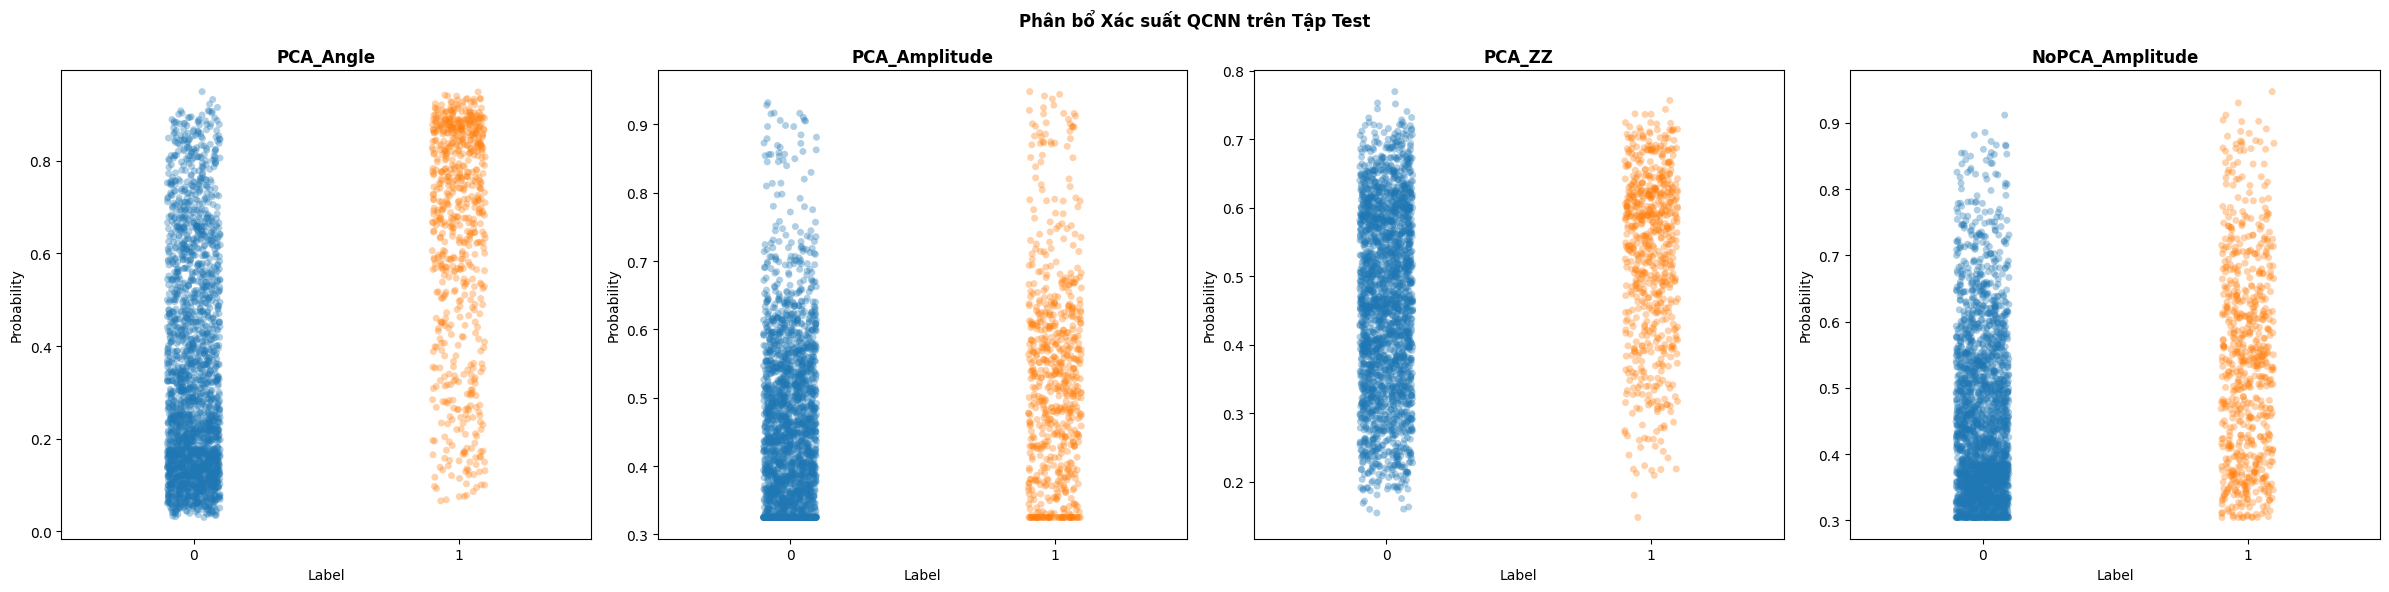

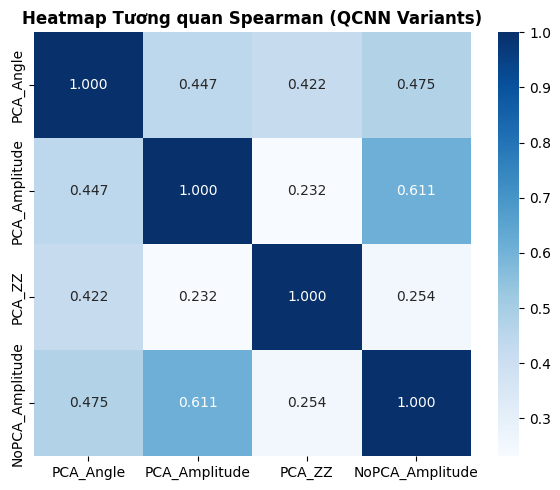

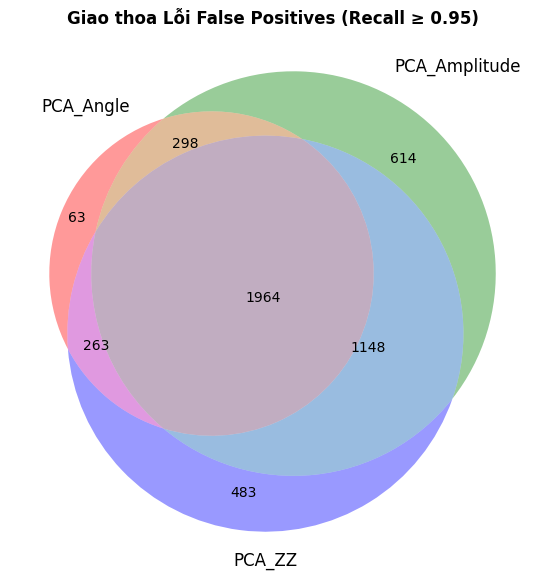

⚠️ Venn chỉ hiển thị 3 models đầu. Còn lại: ['NoPCA_Amplitude']


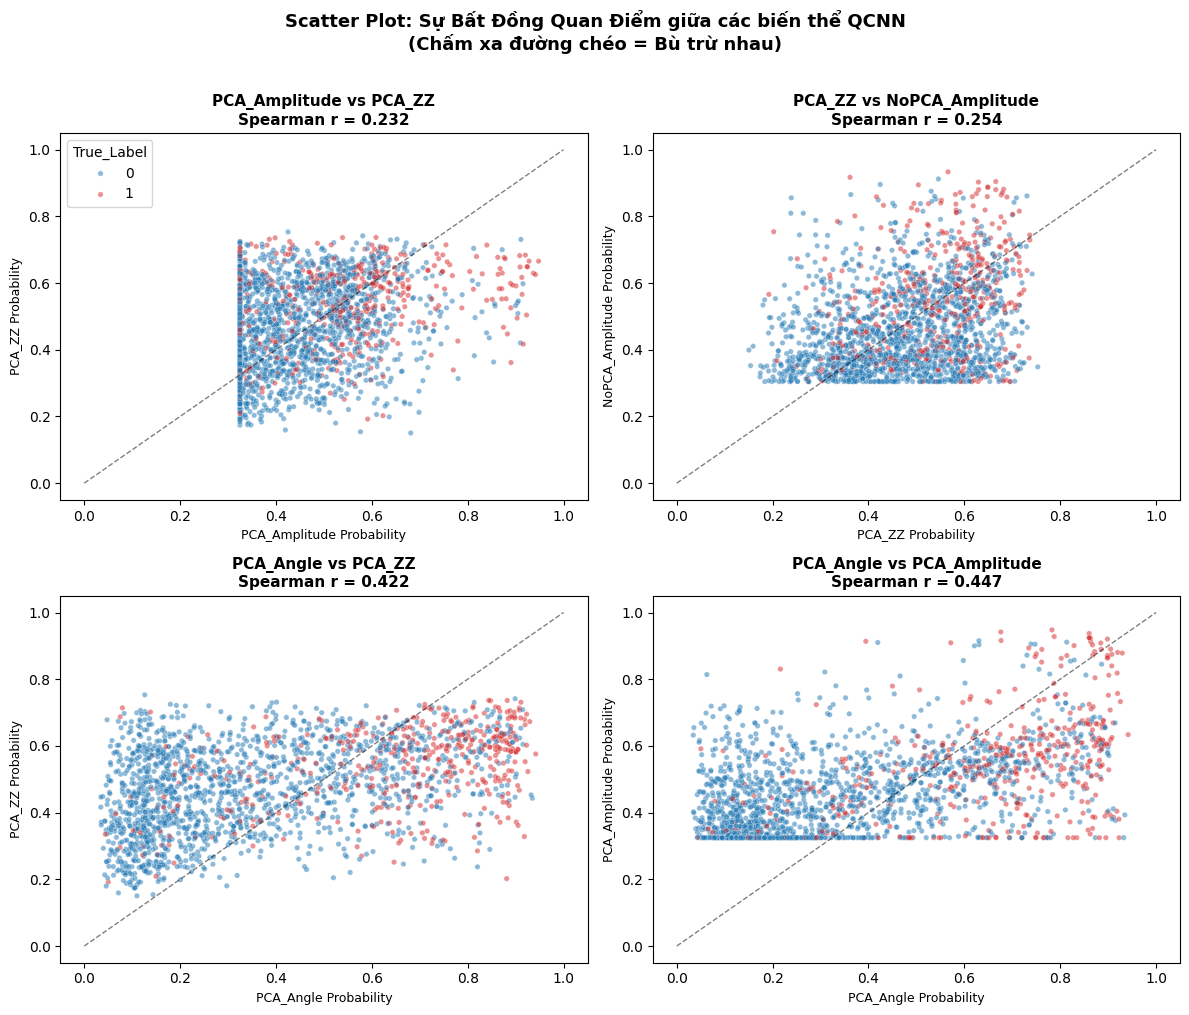

In [8]:
if all_probs:
    names  = list(all_probs)
    y_true = pd.read_parquet(
        Path('quantum_results') / names[0] / 'test_predictions.parquet'
    ).y_true.to_numpy()
    rng_ix = np.random.default_rng(RANDOM_SEED)
    ix     = rng_ix.choice(len(y_true), min(3000, len(y_true)), replace=False)

    # 6.1 Stripplot phân bổ xác suất
    fig, axes = plt.subplots(1, len(names), figsize=(6*len(names), 6))
    axes = np.atleast_1d(axes)
    for ax, name in zip(axes, names):
        sns.stripplot(
            data=pd.DataFrame({'Label': y_true[ix], 'Probability': all_probs[name][ix]}),
            x='Label', y='Probability', hue='Label', legend=False, alpha=0.35, ax=ax
        )
        ax.set_title(name, fontweight='bold')
    plt.suptitle("Phân bổ Xác suất QCNN trên Tập Test", fontweight='bold')
    plt.tight_layout(); plt.show()

if len(all_probs) >= 2:
    # 6.2 Heatmap tương quan Spearman
    corr = pd.DataFrame(all_probs).corr(method='spearman')
    plt.figure(figsize=(max(6, len(names)+2), max(5, len(names)+1)))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt='.3f')
    plt.title('Heatmap Tương quan Spearman (QCNN Variants)', fontweight='bold')
    plt.tight_layout(); plt.show()

    # 6.3 Venn Diagram lỗi False Positives
    fp_names = list(fp_sets)
    plt.figure(figsize=(8, 7))
    if len(fp_names) == 2:
        venn2([fp_sets[fp_names[0]], fp_sets[fp_names[1]]], set_labels=fp_names)
    elif len(fp_names) >= 3:
        venn3([fp_sets[fp_names[0]], fp_sets[fp_names[1]], fp_sets[fp_names[2]]],
              set_labels=fp_names[:3])
    plt.title("Giao thoa Lỗi False Positives (Recall ≥ 0.95)", fontweight='bold')
    plt.show()
    if len(fp_names) > 3:
        print(f"⚠️ Venn chỉ hiển thị 3 models đầu. Còn lại: {fp_names[3:]}")

    # 6.4 Scatter Plot: Bất Đồng Quan Điểm
    from itertools import combinations
    pairs = list(combinations(names, 2))
    
    # Tính Spearman cho mọi cặp và chọn 4 cặp ít tương quan nhất (r nhỏ nhất)
    # Nếu ít model thì lấy tất cả
    pair_corrs = [(p, corr.loc[p[0], p[1]]) for p in pairs]
    pair_corrs.sort(key=lambda x: x[1])
    selected_pairs = [p[0] for p in pair_corrs[:min(4, len(pairs))]]
    
    # Tạo dataframe gom kết quả
    df_probs = pd.DataFrame(all_probs)
    df_probs['True_Label'] = y_true
    
    # Lấy mẫu 2000 ca để vẽ cho nhẹ
    sample_idx = np.random.choice(len(df_probs), size=min(2000, len(df_probs)), replace=False)
    sample_df = df_probs.iloc[sample_idx]
    
    cols = 2
    rows = int(np.ceil(len(selected_pairs) / cols))
    if rows == 0: rows = 1
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, (m1, m2) in enumerate(selected_pairs):
        ax = axes[i]
        sns.scatterplot(
            data=sample_df, x=m1, y=m2, 
            hue='True_Label', alpha=0.5, 
            palette={0: '#1f77b4', 1: '#d62728'}, 
            s=15, legend=(i == 0), ax=ax
        )
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        
        spearman_r = corr.loc[m1, m2]
        ax.set_title(f"{m1} vs {m2}\nSpearman r = {spearman_r:.3f}", fontweight='bold', fontsize=11)
        ax.set_xlabel(f"{m1} Probability", fontsize=9)
        ax.set_ylabel(f"{m2} Probability", fontsize=9)
    
    for j in range(len(selected_pairs), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Scatter Plot: Sự Bất Đồng Quan Điểm giữa các biến thể QCNN\n(Chấm xa đường chéo = Bù trừ nhau)",
                 fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
